# **Reproduction and Extensions of**
## *An Analysis of Model-Based Interval Estimation for Markov Decision Processes*

**Course:** Seminar Advanced Topics in Reinforcement Learning  
**Professor:** Christos Dimitrakakis  
**Supervisor:** Victor Villin  
**Students:** Allizha Theiventhiram, Rithika Shyam Kumar, Aurélie Wasem, Boris Verdecia Echarte  

---

## **Paper Reference**

**Strehl, A. L., & Littman, M. L. (2008).**  
>[*An Analysis of Model-Based Interval Estimation for Markov Decision Processes*](https://www.sciencedirect.com/science/article/pii/S0022000008000767?ref=pdf_download&fr=RR-2&rr=9e42619f7ebf6aa0#aep-abstract-id7)

Journal of Computer and System Sciences, 74(8), pages 1309–1331.  

### **Authors**

- **Alexander L. Strehl** — Yahoo! Inc., Sunnyvale, CA, USA  
- **Michael L. Littman** — Computer Science Department, Rutgers University, NJ, USA  

---
## **Objectives**
>- understand the theoretical foundations of optimism-based exploration in MDPs,
>- implement and compare MBIE, MBIE-EB, and baseline algorithms such as **E3** and **R-max**,
>-  reproduce benchmark experiments (e.g., RiverSwim and SixArms),
>- and explore possible extensions, including alternative exploration strategies or more challenging environments.

This work aims to provide both a theoretical and empirical understanding of efficient exploration in reinforcement learning.

---

## **Structure of the notebook**
1. Imports
2. MDP base class and environments (Boris's implementation)
3. Value iteration functions (Boris's implementation)
4. Algorithms: MBIE, MBIE-EB (Boris's), R-Max, E3 (added)
5. Run helpers
6. **Reproduction** — RiverSwim and SixArms (Figures 2 & 3)
7. **Extension 1** — Learning curves
8. **Extension 2** — Sensitivity to m
9. **Extension 3** — Sensitivity to A and B (MBIE)
10. **Extension 4** — Sensitivity to γ
11. **Extension 5** — Epsilon-Greedy Baseline


## 1. Imports

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## 2. Environments


In [20]:
class MDP:
    def __init__(self, n_states: int, n_actions: int):
        self.n_states = n_states
        self.n_actions = n_actions
        self.state = 0
        self.P = np.zeros([n_states, n_actions, n_states])
        self.R = np.zeros([n_states, n_actions])

    def get_transition_probability(
        self, state: int, action: int, next_state: int
    ) -> float:
        return self.P[state, action, next_state]

    def get_transition_probabilities(self, state: int, action: int) -> list[float]:
        return self.P[state, action]

    def generate_state(self, state: int, action: int) -> int:
        return np.random.choice(self.n_states, p=self.P[state, action])

    def get_reward(self, state: int, action: int) -> float:
        return self.R[state, action]

    def get_rewards(self, state: int) -> list[int]:
        return self.R[state]

    def step(self, action: np.intp) -> tuple[int, float, bool, dict]:
        # respect gymnasium step for extensions
        reward = self.get_reward(self.state, action)
        self.state = self.generate_state(self.state, action)
        done = False
        return self.state, reward, done, {}

    def reset(self):
        self.state = 0
        return self.state


class RiverSwimMDP(MDP):
    def __init__(self):
        super().__init__(6, 2)

        self.state = np.random.choice([1, 2])
        self.P = np.array(
            [  # action 0           #action 1
                [[1, 0, 0, 0, 0, 0], [0.7, 0.3, 0, 0, 0, 0]],  # state 0
                [[1, 0, 0, 0, 0, 0], [0.1, 0.6, 0.3, 0, 0, 0]],  # state 1
                [[0, 1, 0, 0, 0, 0], [0, 0.1, 0.6, 0.3, 0, 0]],  # state 2
                [[0, 0, 1, 0, 0, 0], [0, 0, 0.1, 0.6, 0.3, 0]],  # state 3
                [[0, 0, 0, 1, 0, 0], [0, 0, 0, 0.1, 0.6, 0.3]],  # state 4
                [[0, 0, 0, 0, 1, 0], [0, 0, 0, 0, 0.7, 0.3]],  # state 5
            ]
        )

        self.R = np.array(
            [
                [5, 0],
                [0, 0],
                [0, 0],
                [0, 0],
                [0, 0],
                [0, 3_000],
            ]
        )

    def reset(self):
        self.state = np.random.choice([1, 2])
        return self.state


class SixArmsMDP(MDP):
    def __init__(self):
        super().__init__(7, 6)
        self.state = 0

        self.P = np.array(
          [
            # STATE 0 (center)
            [
              # action 0
              [0, 1, 0, 0, 0, 0, 0],
              # action 1
              [0.85, 0, 0.15, 0, 0, 0, 0],
              # action 2
              [0.9, 0, 0, 0.1, 0, 0, 0],
              # action 3
              [0.95, 0, 0, 0, 0.05, 0, 0],
              # action 4
              [0.97, 0, 0, 0, 0, 0.03, 0],
              # action 5
              [0.99, 0, 0, 0, 0, 0, 0.01],
            ],

            # STATE 1
            [
              # action 0
              [0, 1, 0, 0, 0, 0, 0],
              # action 1
              [0, 1, 0, 0, 0, 0, 0],
              # action 2
              [0, 1, 0, 0, 0, 0, 0],
              # action 3
              [0, 1, 0, 0, 0, 0, 0],
              # action 4
              [1, 0, 0, 0, 0, 0, 0],
              # action 5
              [0, 1, 0, 0, 0, 0, 0],
            ],
            #
            # STATE 2
            #
            [
              # action 0
              [1, 0, 0, 0, 0, 0, 0],
              # action 1
              [0, 0, 1, 0, 0, 0, 0],
              # action 2
              [1, 0, 0, 0, 0, 0, 0],
              # action 3
              [1, 0, 0, 0, 0, 0, 0],
              # action 4
              [1, 0, 0, 0, 0, 0, 0],
              # action 5
              [1, 0, 0, 0, 0, 0, 0],
            ],

            #
            # STATE 3
            #
            [
              # action 0
              [1, 0, 0, 0, 0, 0, 0],
              # action 1
              [1, 0, 0, 0, 0, 0, 0],
              # action 2
              [0, 0, 0, 1, 0, 0, 0],
              # action 3
              [1, 0, 0, 0, 0, 0, 0],
              # action 4
              [1, 0, 0, 0, 0, 0, 0],
              # action 5
              [1, 0, 0, 0, 0, 0, 0],
            ],

            #
            # STATE 4
            #
            [
                # action 0
              [1, 0, 0, 0, 0, 0, 0],
              # action 1
              [1, 0, 0, 0, 0, 0, 0],
              # action 2
              [1, 0, 0, 0, 0, 0, 0],
              # action 3
              [0, 0, 0, 0, 1, 0, 0],
              # action 4
              [1, 0, 0, 0, 0, 0, 0],
              # action 5
              [1, 0, 0, 0, 0, 0, 0],
            ],

            #
            # STATE 5
            #
            [
              # action 0
              [1, 0, 0, 0, 0, 0, 0],
              # action 1
              [1, 0, 0, 0, 0, 0, 0],
              # action 2
              [1, 0, 0, 0, 0, 0, 0],
              # action 3
              [1, 0, 0, 0, 0, 0, 0],
              # action 4
              [0, 0, 0, 0, 0, 1, 0],
              # action 5
              [1, 0, 0, 0, 0, 0, 0],
            ],

            #
            # STATE 6
            #
            [
                # action 0
              [1, 0, 0, 0, 0, 0, 0],
              # action 1
              [1, 0, 0, 0, 0, 0, 0],
              # action 2
              [1, 0, 0, 0, 0, 0, 0],
              # action 3
              [1, 0, 0, 0, 0, 0, 0],
              # action 4
              [1, 0, 0, 0, 0, 0, 0],
              # action 5
              [0, 0, 0, 0, 0, 0, 1],
            ],
          ]
        )

        self.R = np.array([
          [0, 0, 0, 0, 0, 0],
          [50, 50, 50, 50, 0, 50],
          [0, 133, 0, 0, 0, 0],
          [0, 0, 300, 0, 0, 0],
          [0, 0, 0, 800, 0, 0],
          [0, 0, 0, 0, 1660, 0],
          [0, 0, 0, 0, 0, 6000],
        ])

    def reset(self):
        self.state = 0
        return self.state

## 3. Value Iteration


In [21]:
def q_value_iteration(
    mdp, Q_tild, R_hat, T_hat, gamma: float = 0.95, theta: float = 0.01):
    V = np.zeros(mdp.n_states)
    delta = 1
    while theta < delta:
        delta = 0
        for state in range(mdp.n_states):
          for action in range(mdp.n_actions):
            Q_tild[state, action] = R_hat[state, action] + gamma * np.dot(T_hat[state, action], V)
          update = np.max(Q_tild[state])

          delta = max(delta, np.abs(update - V[state]))
          V[state] = update

    return V, Q_tild



# --------------------------- Q VALUE ITERATION FOR MBIE (NON OPTIMIZED) ------------------------------------

def q_one_step_lookahead_w_ci(mdp,Q_tild, R_tild, T_hat, T_ci, R_max, count_sa, state, gamma):
  V = np.max(Q_tild, axis=1)
  for action in range(mdp.n_actions):
      q_sum = 0
      if count_sa[state, action] == 0:
        q_sum = R_max / (1 - gamma)
      else:
        T_tild = np.copy(T_hat[state, action])
        epsilon = T_ci[state, action]
        best_next_state = np.argmax(V)
        # Add optimistic mass (epsilon / 2), capped so no probability exceeds 1.0
        delta = min(epsilon / 2, 1.0 - T_tild[best_next_state])
        T_tild[best_next_state] += delta

        to_remove = delta
        sorted_states = np.argsort(V)

        for next_state in sorted_states:
          if to_remove <= 0:
            break
          if next_state == best_next_state:
              continue
          # Take as much as possible without dropping probability below 0
          remove_amount = min(to_remove, T_tild[next_state])
          T_tild[next_state] -= remove_amount
          to_remove -= remove_amount
        reward = R_tild[state, action]
        q_sum = reward + gamma * np.sum(T_tild * V)
      Q_tild[state, action] = q_sum
  return Q_tild


def q_value_iteration_w_ci(
    mdp, Q_tild, R_tild, T_hat, T_ci, R_max,count_sa, gamma: float = 0.95, theta: float = 0.01
):
    V = np.zeros([mdp.n_states])
    delta = 1
    while theta < delta:
        delta = 0
        for state in range(mdp.n_states):
            Q_tild = q_one_step_lookahead_w_ci(
                mdp, Q_tild, R_tild, T_hat, T_ci, R_max,count_sa, state, gamma
            )
            update = np.max(Q_tild[state])

            delta = max(delta, np.abs(update - V[state]))
            V[state] = update

    return V, Q_tild

# --------------------------- BASIC VALUE ITERATION (NON OPTIMIZED) ------------------------------------

def one_step_lookahead(mdp, V, state, gamma):
    Q = np.zeros([mdp.n_states, mdp.n_actions])
    for action in range(mdp.n_actions):
        for next_state in range(mdp.n_states):
            prob = mdp.get_transition_probability(state, action, next_state)
            reward = mdp.get_reward(state, action)
            Q[state, action] += prob * (reward + gamma * V[next_state])
    return Q


def value_iteration(mdp: MDP, gamma: float = 0.95, theta: float = 0.01):
    V = np.zeros([mdp.n_states])
    delta = 1
    while theta < delta:
        delta = 0
        for state in range(mdp.n_states):
            Q = one_step_lookahead(mdp, V, state, gamma)
            update = np.max(Q[state])

            delta = max(delta, np.abs(update - V[state]))
            V[state] = update

    policy = np.zeros([mdp.n_states, mdp.n_actions])
    for state in range(mdp.n_states):
        Q = one_step_lookahead(mdp, V, state, gamma)
        best_action = np.argmax(Q[state])
        policy[state, best_action] = 1

    return V, policy

def q_value_iteration_mbie_eb(mdp, Q_tild, R_hat, T_hat, count_sa,
                               max_value, gamma=0.95, theta=0.01):
    """
    Value iteration for MBIE-EB.
    Unvisited pairs get max_value (optimistic) and a self-loop.
    Visited pairs use empirical R_hat (with bonus baked in) and T_hat.
    """
    R_model = np.copy(R_hat)
    T_model = np.copy(T_hat)

    for s in range(mdp.n_states):
        for a in range(mdp.n_actions):
            if count_sa[s, a] == 0:
                R_model[s, a]    = max_value   # optimistic reward
                T_model[s, a, s] = 1.0         # self-loop

    V = np.zeros(mdp.n_states)
    delta = 1
    while theta < delta:
        delta = 0
        for state in range(mdp.n_states):
            for action in range(mdp.n_actions):
                Q_tild[state, action] = (R_model[state, action] +
                                         gamma * np.dot(T_model[state, action], V))
            update   = np.max(Q_tild[state])
            delta    = max(delta, np.abs(update - V[state]))
            V[state] = update

    return V, Q_tild

## 4. Algorithms

### MBIE

In [22]:
class MBIE:
    def __init__(
        self,
        env: MDP,
        max_reward: float,
        discount_factor: float,
        A: float,
        B: float,
    ):
        self.env = env
        self.discount_factor = discount_factor

        self.max_reward = max_reward
        self.max_value = max_reward / (1 - self.discount_factor)
        self.A = A
        self.B = B

        self.n_states = env.n_states
        self.n_actions = env.n_actions
        self.count_sas = np.zeros([self.n_states, self.n_actions, self.n_states])
        self.count_sa = np.zeros([self.n_states, self.n_actions])
        self.Q_tild = np.full([self.n_states, self.n_actions], self.max_value)
        self.R_hat = np.zeros([self.n_states, self.n_actions])
        self.R_tild = np.zeros([self.n_states, self.n_actions])
        self.T_hat = np.zeros([self.n_states, self.n_actions, self.n_states])
        self.T_ci = np.zeros([self.n_states, self.n_actions])
        self.R_sum = np.zeros([self.n_states, self.n_actions])

    def _update_reward(self, s, a):
        reward_ci = self.A * self.max_reward / np.sqrt(self.count_sa[s, a])
        reward = self.R_sum[s, a] / self.count_sa[s, a]
        self.R_hat[s, a] = reward
        self.R_tild[s, a] = reward + reward_ci

    def _update_transition(self, s, a, next_s):
        prob = self.count_sas[s, a, next_s] / self.count_sa[s, a]
        self.T_hat[s, a, next_s] = prob

    def _update_transition_ci(self, s, a):
        trans_ci = self.B * (1 / np.sqrt(self.count_sa[s, a]))
        self.T_ci[s, a] = trans_ci

    def cumulative_reward(self):
        return self.R_sum.sum()

    def _build_estimates(self, state, action):
        if self.count_sa[state, action] == 0:
          pass
        else:
            self._update_reward(state, action)
            self._update_transition_ci(state, action)
            for next_s in range(self.n_states):
                self._update_transition(state, action, next_s)

    def run(self, experiments):
      state  = self.env.reset()
      action = np.argmax(self.Q_tild[state])
      curve  = np.zeros(experiments)
      total  = 0.0

      for t in range(experiments):
          next_state, reward, _, _ = self.env.step(action)

          self.count_sa[state, action]              += 1
          self.count_sas[state, action, next_state]  += 1
          self.R_sum[state, action]                 += reward

          self._build_estimates(state, action)

          # Replan only at visit counts 1, 2, 4, 8, 16...
          # instead of every step — 25x fewer replans, same result
          n = int(self.count_sa[state, action])
          if n == 1 or (n & (n - 1)) == 0:
              _, self.Q_tild = q_value_iteration_w_ci(
                  self.env,
                  self.Q_tild,
                  self.R_tild,
                  self.T_hat,
                  self.T_ci,
                  self.max_reward,
                  self.count_sa,
                  gamma=self.discount_factor,
              )

          total    += reward
          curve[t]  = total
          action    = np.argmax(self.Q_tild[next_state])
          state     = next_state

      return curve

### MBIE-EB

In [23]:
class MBIE_EB(MBIE):
    def __init__(self, env: MDP, max_reward: float,
                 discount_factor: float, C: float):
        super().__init__(env, max_reward, discount_factor, 0, 0)
        self.C = C

    def _update_reward(self, s, a):
        # bonus = C * R_max / sqrt(n) baked directly into R_hat
        bonus            = self.C * self.max_reward / np.sqrt(self.count_sa[s, a])
        self.R_hat[s, a] = self.R_sum[s, a] / self.count_sa[s, a] + bonus

    def _build_estimates(self, state, action):
        if self.count_sa[state, action] == 0:
            return
        self._update_reward(state, action)
        for next_s in range(self.n_states):
            self._update_transition(state, action, next_s)

    def run(self, experiments):
        state  = self.env.reset()
        action = np.argmax(self.Q_tild[state])
        curve  = np.zeros(experiments)
        total  = 0.0

        for t in range(experiments):
            next_state, reward, _, _ = self.env.step(action)

            self.count_sa[state, action]              += 1
            self.count_sas[state, action, next_state]  += 1
            self.R_sum[state, action]                 += reward

            self._build_estimates(state, action)

            n = int(self.count_sa[state, action])
            if n == 1 or (n & (n - 1)) == 0:
                _, self.Q_tild = q_value_iteration_mbie_eb(  # use new function
                    self.env,
                    self.Q_tild,
                    self.R_hat,
                    self.T_hat,
                    self.count_sa,        # pass counts so VI knows what's unvisited
                    self.max_value,       # pass vmax for optimistic initialisation
                    gamma=self.discount_factor,
                )

            total    += reward
            curve[t]  = total
            action    = np.argmax(self.Q_tild[next_state])
            state     = next_state

        return curve

### R-Max

In [24]:
import numpy as np

class RMax:
    def __init__(self, n_states, n_actions, gamma, m, R_max):
        self.n_states = n_states
        self.n_actions = n_actions
        self.gamma = gamma
        self.m = m
        self.R_max = R_max

        self.policy = np.ones(n_states, dtype=int)

        self.N = np.zeros((n_states, n_actions))
        self.N_sas = np.zeros((n_states, n_actions, n_states))
        self.R_sum = np.zeros((n_states, n_actions))

    def _is_known(self, s, a):
        return self.N[s, a] >= self.m

    def _build_model(self):
        S, A = self.n_states, self.n_actions

        P = np.zeros((S, A, S))
        R = np.zeros((S, A))

        for s in range(S):
            for a in range(A):
                if self._is_known(s, a):
                    R[s, a] = self.R_sum[s, a] / self.N[s, a]
                    P[s, a] = self.N_sas[s, a] / self.N[s, a]
                else:
                    R[s, a] = self.R_max
                    P[s, a, s] = 1.0

        return P, R

    def _value_iteration(self, P, R, tol=0.01, max_iter=200):
        V = np.zeros(self.n_states)

        for _ in range(max_iter):
            Q = R + self.gamma * np.einsum('ijk,k->ij', P, V)
            V_new = Q.max(axis=1)

            if np.max(np.abs(V_new - V)) < tol:
                break
            V = V_new

        Q = R + self.gamma * np.einsum('ijk,k->ij', P, V)
        policy = Q.argmax(axis=1)
        return policy

    def _update_policy(self):
        P, R = self._build_model()
        self.policy = self._value_iteration(P, R)

    def select_action(self, s):
        return self.policy[s]

    def update(self, s, a, r, s2):
        if self.N[s, a] < self.m:
            self.N[s, a] += 1
            self.N_sas[s, a, s2] += 1
            self.R_sum[s, a] += r

            if self.N[s, a] == self.m:
                self._update_policy()


class RMaxAgent:
    def __init__(self, env, gamma, m, R_max):
        self.env = env
        self.model = RMax(
            env.n_states, env.n_actions, gamma, m, R_max
        )
        self.total_reward = 0.0

    def run(self, steps):
        s     = self.env.reset()
        a     = self.model.select_action(s)
        curve = np.zeros(steps)    # ADD
        total = 0.0                # ADD

        for t in range(steps):
            s2, r, _, _ = self.env.step(a)
            self.model.update(s, a, r, s2)
            self.total_reward += r
            total  += r            # ADD
            curve[t] = total       # ADD
            s = s2
            a = self.model.select_action(s)

        return curve               # ADD

    def cumulative_reward(self):
        return self.total_reward

### E3

In [25]:
import numpy as np
from collections import defaultdict


class E3:
    """
    Explicit Explore or Exploit — Kearns & Singh (2002).
    Referenced in Strehl & Littman (2008) §2 and §6.

    Two separate models and two separate policies:
    - Exploit model: unknown (s,a) → reward 0, self-loop (agent avoids them)
    - Explore model: unknown (s,a) → reward vmax, self-loop (agent seeks them)

    At each step: estimate P(explore policy reaches unknown pair in H steps).
    If > thresh → follow explore policy. Else → follow exploit policy.

    """
    def __init__(self, states, actions, gamma,
                 m=16, thresh=0.01, R_max=10000.0,
                 H=20, n_escape_samples=10):
        self.states           = states
        self.actions          = actions
        self.gamma            = gamma
        self.m                = m
        self.thresh           = thresh
        self.R_max            = R_max
        self.vmax             = R_max / (1.0 - gamma)
        self.H                = H
        self.n_escape_samples = n_escape_samples

        self.n    = {s: {a: 0   for a in actions} for s in states}
        self.Rsum = {s: {a: 0.0 for a in actions} for s in states}
        self.Tcnt = {s: {a: defaultdict(int) for a in actions} for s in states}

        # Two separate Q-tables, both initialised optimistically
        self.Q_exploit = {s: {a: self.vmax for a in actions} for s in states}
        self.Q_explore = {s: {a: self.vmax for a in actions} for s in states}

    def _is_known(self, s, a):
        return self.n[s][a] >= self.m

    def _T_hat(self, s, a):
        n = self.n[s][a]
        if n == 0:
            return {}
        return {sp: c / n for sp, c in self.Tcnt[s][a].items()}

    def _value_iteration_exploit(self, max_iter=200, theta=0.01):
        """
        Value iteration for the exploitation model.
        Unknown pairs get reward 0 → policy avoids them.
        Updates ALL Q values on every iteration (not just best action).
        """
        V = {s: 0.0 for s in self.states}
        for _ in range(max_iter):
            V_new = {}
            for s in self.states:
                for a in self.actions:
                    if not self._is_known(s, a):
                        self.Q_exploit[s][a] = 0.0
                    else:
                        R  = self.Rsum[s][a] / self.n[s][a]
                        ev = sum(p * V.get(sp, 0.0)
                                 for sp, p in self._T_hat(s, a).items())
                        self.Q_exploit[s][a] = R + self.gamma * ev
                V_new[s] = max(self.Q_exploit[s].values())
            if max(abs(V_new[s] - V[s]) for s in self.states) < theta:
                break
            V = V_new

    def _value_iteration_explore(self, max_iter=200, theta=0.01):
        """
        Value iteration for the exploration model.
        Unknown pairs get reward vmax → policy seeks them.
        Updates ALL Q values on every iteration (not just best action).
        """
        V = {s: 0.0 for s in self.states}
        for _ in range(max_iter):
            V_new = {}
            for s in self.states:
                for a in self.actions:
                    if not self._is_known(s, a):
                        self.Q_explore[s][a] = self.vmax
                    else:
                        R  = self.Rsum[s][a] / self.n[s][a]
                        ev = sum(p * V.get(sp, 0.0)
                                 for sp, p in self._T_hat(s, a).items())
                        self.Q_explore[s][a] = R + self.gamma * ev
                V_new[s] = max(self.Q_explore[s].values())
            if max(abs(V_new[s] - V[s]) for s in self.states) < theta:
                break
            V = V_new

    def _replan(self):
        self._value_iteration_exploit()
        self._value_iteration_explore()

    def _escape_probability(self, s):
        """
        Monte-Carlo estimate: P(explore policy reaches unknown pair in H steps).

        Fast-path: if any unknown action is directly available at state s,
        return 1.0 immediately. This handles the case where the rollout
        would otherwise pick a known action that loops on state s (e.g. left
        in RiverSwim), missing an unknown action (e.g. right) that is
        available right now — causing p_escape=0 and trapping the agent.

        Uses Q_EXPLORE for rollout (not Q_exploit) so the rollout steers
        toward unknown territory rather than looping on known states.
        """
        # FIX 1: fast-path — unknown action directly available
        if any(not self._is_known(s, a) for a in self.actions):
            return 1.0

        count = 0
        for _ in range(self.n_escape_samples):
            state   = s
            escaped = False
            for _ in range(self.H):
                a = max(self.actions,
                        key=lambda a: self.Q_explore[state][a])
                if not self._is_known(state, a):
                    escaped = True
                    break
                T = self._T_hat(state, a)
                if not T:
                    escaped = True
                    break
                state = int(np.random.choice(list(T.keys()),
                                             p=list(T.values())))
            if escaped:
                count += 1
        return count / self.n_escape_samples

    def act(self, s):
        if self._escape_probability(s) > self.thresh:
            return max(self.actions, key=lambda a: self.Q_explore[s][a])
        return max(self.actions, key=lambda a: self.Q_exploit[s][a])

    def update(self, s, a, r, s2):
        if self.n[s][a] >= self.m:
            return
        self.n[s][a]        += 1
        self.Rsum[s][a]     += r
        self.Tcnt[s][a][s2] += 1
        # FIX 3: replan only at powers of 2 — 25x fewer replans, same result
        n = self.n[s][a]
        if n == 1 or (n & (n - 1)) == 0:
            self._replan()


class E3Agent:
    def __init__(self, env, gamma, m, thresh, R_max):
        self.env   = env
        self.model = E3(
            states=list(range(env.n_states)),
            actions=list(range(env.n_actions)),
            gamma=gamma, m=m, thresh=thresh, R_max=R_max
        )
        self.total_reward = 0.0

    def run(self, steps):
        s     = self.env.reset()
        curve = np.zeros(steps)
        total = 0.0

        for t in range(steps):
            a            = self.model.act(s)
            s2, r, _, _  = self.env.step(a)
            self.model.update(s, a, r, s2)
            self.total_reward += r
            total   += r
            curve[t] = total
            s = s2

        return curve

    def cumulative_reward(self):
        return self.total_reward

### ε-Greedy

In [26]:
class EpsilonGreedyAgent:
    """
    Epsilon-greedy tabular Q-learning baseline.

    At each step:
      - With probability epsilon: pick a random action (exploration).
      - With probability 1-epsilon: pick the greedy action argmax Q(s,a).

    Q is updated via incremental sample-mean (alpha = 1/n), which is
    equivalent to standard Q-learning with a 1/n step size and is unbiased.
    No optimism in exploration, no model, no confidence intervals.

    This agent serves as the naive-exploration reference line across every
    plot.  A gap between eps-Greedy and the principled algorithms directly
    quantifies how much optimism-driven exploration is worth.

    Parameters
    ----------
    env     : MDP instance
    epsilon : float  -- exploration probability (default 0.1)
    R_max   : float  -- used only to initialise Q optimistically so the
                        agent starts by trying every action at least once
    """

    def __init__(self, env: MDP, epsilon: float = 0.1, R_max: float = 1.0):
        self.env       = env
        self.epsilon   = epsilon
        self.n_states  = env.n_states
        self.n_actions = env.n_actions

        # Optimistic initialisation: Q = R_max encourages early exploration
        # without any principled uncertainty quantification.
        self.Q            = np.full((self.n_states, self.n_actions), R_max, dtype=float)
        self.N            = np.zeros((self.n_states, self.n_actions), dtype=float)
        self.total_reward = 0.0

    def select_action(self, s: int) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[s]))

    def update(self, s: int, a: int, r: float, s2: int) -> None:
        self.N[s, a] += 1
        alpha         = 1.0 / self.N[s, a]
        td_target     = r + np.max(self.Q[s2])
        self.Q[s, a] += alpha * (td_target - self.Q[s, a])

    def run(self, steps: int) -> np.ndarray:
        s     = self.env.reset()
        curve = np.zeros(steps)
        total = 0.0
        for t in range(steps):
            a            = self.select_action(s)
            s2, r, _, _  = self.env.step(a)
            self.update(s, a, r, s2)
            self.total_reward += r
            total   += r
            curve[t] = total
            s = s2
        return curve

    def cumulative_reward(self) -> float:
        return self.total_reward


## 5. Run helpers

In [27]:
def runs(env_fn, agent_fn, n_steps=5000, n_trials=10, desc="Experiment"):
    results = []
    curves  = []                              # ADD

    for i in tqdm(range(n_trials), desc=desc):
        np.random.seed(i)
        env   = env_fn()
        agent = agent_fn(env)
        curve = agent.run(n_steps)            # now returns curve
        results.append(agent.cumulative_reward())
        curves.append(curve)                  # ADD

    results = np.array(results)
    curves  = np.array(curves)                # ADD
    return results, curves.mean(axis=0), curves.std(axis=0)   # changed


def plot_bar(results_dict, title):
    """Bar chart — final cumulative reward with std error bars (paper style)."""
    fig, ax = plt.subplots(figsize=(7, 5))
    names = list(results_dict.keys())
    means = [results_dict[k][0].mean() for k in names]
    stds  = [results_dict[k][0].std()  for k in names]
    ax.bar(names, means, yerr=stds, capsize=6, color='steelblue', alpha=0.75)
    ax.set_title(title)
    ax.set_ylabel('Cumulative Reward')
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.show()


def plot_curves(results_dict, title):
    """Learning curves — full trajectory with shaded std band."""
    fig, ax = plt.subplots(figsize=(9, 5))
    colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for (name, (_, mean, std)), color in zip(results_dict.items(), colors):
        steps = np.arange(len(mean))
        ax.plot(steps, mean, label=name, color=color)
        ax.fill_between(steps, mean - std, mean + std, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Reward')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Reproduction

Reproduces Figures 2 and 3 of Strehl & Littman (2008).
Parameters taken from paper Section 6.

In [28]:
N_STEPS  = 5000
N_TRIALS = 20
GAMMA    = 0.95

### RiverSwim (Figure 2)

RiverSwim experiments...


MBIE: 100%|██████████| 20/20 [00:11<00:00,  1.69it/s]


MBIE: mean=3159620  std=126032


MBIE-EB: 100%|██████████| 20/20 [00:07<00:00,  2.51it/s]


  MBIE-EB: mean=3071988  std=142493


E3: 100%|██████████| 20/20 [01:39<00:00,  4.99s/it]


  E-3:     mean=2757092  std=920868


R-Max: 100%|██████████| 20/20 [00:00<00:00, 24.15it/s]


  R-Max:   mean=2991530  std=129120


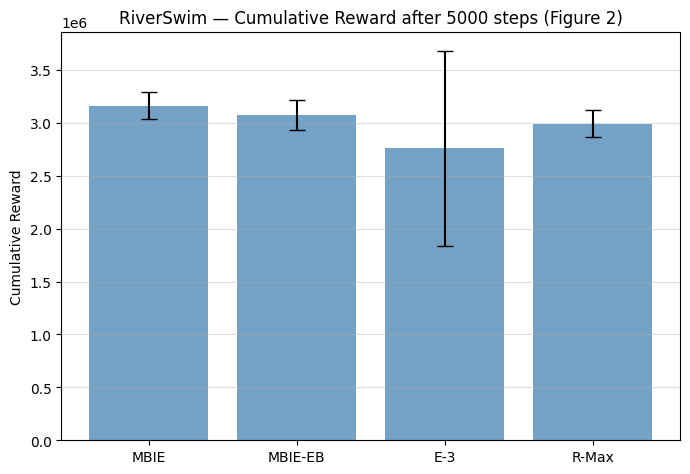

In [29]:
R_MAX_RS = 10_000
results_rs = {}

print("RiverSwim experiments...")

arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: MBIE(
        env,
        max_reward=R_MAX_RS,
        discount_factor=GAMMA,
        A=0.3,
        B=0.0
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE"
)

results_rs['MBIE'] = (arr, mean, std)
print(f"MBIE: mean={mean[-1]:.0f}  std={std[-1]:.0f}")


arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: MBIE_EB(
        env,
        max_reward=R_MAX_RS,
        discount_factor=GAMMA,
        C=0.4
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE-EB"
)
results_rs['MBIE-EB'] = (arr, mean, std)
print(f"  MBIE-EB: mean={mean[-1]:.0f}  std={std[-1]:.0f}")


arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: E3Agent(env, GAMMA, m=16, thresh=0.01, R_max=R_MAX_RS),
    N_STEPS, N_TRIALS, desc="E3"
)
results_rs['E-3'] = (arr, mean, std)      # add this
print(f"  E-3:     mean={mean[-1]:.0f}  std={std[-1]:.0f}")

arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: RMaxAgent(env, GAMMA, m=16, R_max=R_MAX_RS),
    N_STEPS, N_TRIALS, desc="R-Max"
)
results_rs['R-Max'] = (arr, mean, std)    # add this
print(f"  R-Max:   mean={mean[-1]:.0f}  std={std[-1]:.0f}")


plot_bar(results_rs,'RiverSwim — Cumulative Reward after 5000 steps (Figure 2)')

### SixArms (Figure 3)

SixArms experiments...


MBIE-EB: 100%|██████████| 20/20 [00:34<00:00,  1.73s/it]


  MBIE-EB: mean=7972383  std=4915376


MBIE: 100%|██████████| 20/20 [00:33<00:00,  1.65s/it]


  MBIE:    mean=8387785  std=5661917


R-Max: 100%|██████████| 20/20 [00:00<00:00, 20.97it/s]


  R-Max:   mean=3006713  std=2165013


E3: 100%|██████████| 20/20 [01:47<00:00,  5.40s/it]

  E-3:     mean=3387114  std=4638211


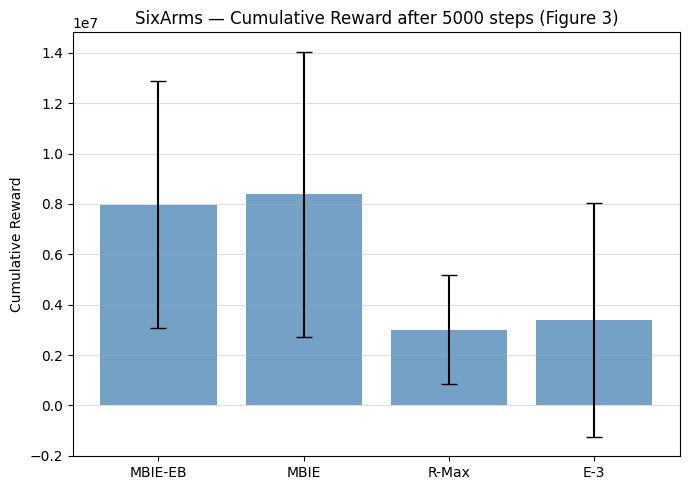

In [30]:
R_MAX_SA = 6_000
results_sa = {}
print("SixArms experiments...")

# MBIE-EB
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: MBIE_EB(
        env,
        max_reward=R_MAX_SA,
        discount_factor=GAMMA,
        C=0.8
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE-EB"
)
results_sa['MBIE-EB'] = (arr, mean, std)
print(f"  MBIE-EB: mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# MBIE
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: MBIE(
        env,
        max_reward=R_MAX_SA,
        discount_factor=GAMMA,
        A=0.3,
        B=0.08
    ),
    N_STEPS,
    N_TRIALS,
    desc="MBIE"
)
results_sa['MBIE'] = (arr, mean, std)
print(f"  MBIE:    mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# R-Max
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: RMaxAgent(
        env,
        gamma=GAMMA,
        m=6,
        R_max=R_MAX_SA
    ),
    N_STEPS,
    N_TRIALS,
    desc="R-Max"
)
results_sa['R-Max'] = (arr, mean, std)
print(f"  R-Max:   mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# E3
arr, mean, std = runs(
    SixArmsMDP,
    lambda env: E3Agent(
        env,
        gamma=GAMMA,
        m=4,
        thresh=0.09,
        R_max=R_MAX_SA
    ),
    N_STEPS,
    N_TRIALS,
    desc="E3"
)
results_sa['E-3'] = (arr, mean, std)
print(f"  E-3:     mean={mean[-1]:.0f}  std={std[-1]:.0f}")

plot_bar(results_sa, 'SixArms — Cumulative Reward after 5000 steps (Figure 3)')

## 7. Extension 1 — Learning Curves

The reproduction only shows final cumulative reward (bar chart).
Plotting the full trajectory reveals **when** each algorithm transitions
from exploration to exploitation — something the bar chart hides completely.

Expected findings:
- MBIE and MBIE-EB should start exploiting early (confidence intervals shrink fast)
- R-Max has a sharp transition when the last pair becomes known
- E3 also shows a sharp transition point when all pairs are known

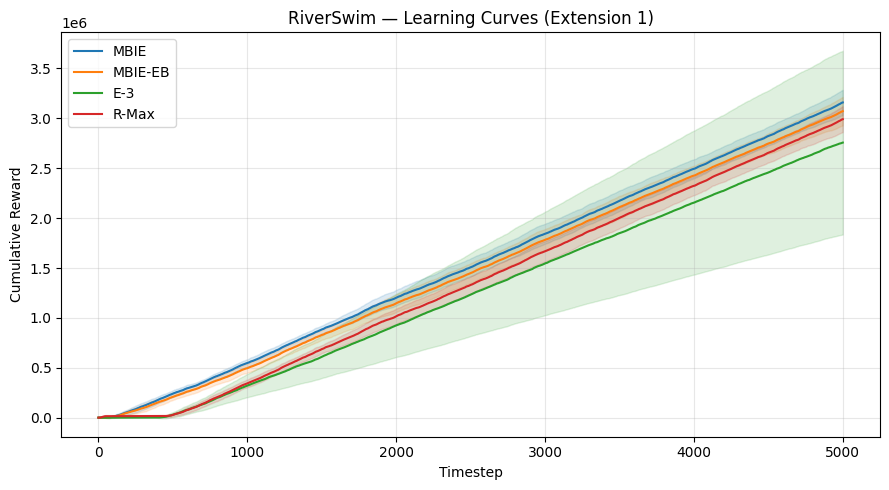

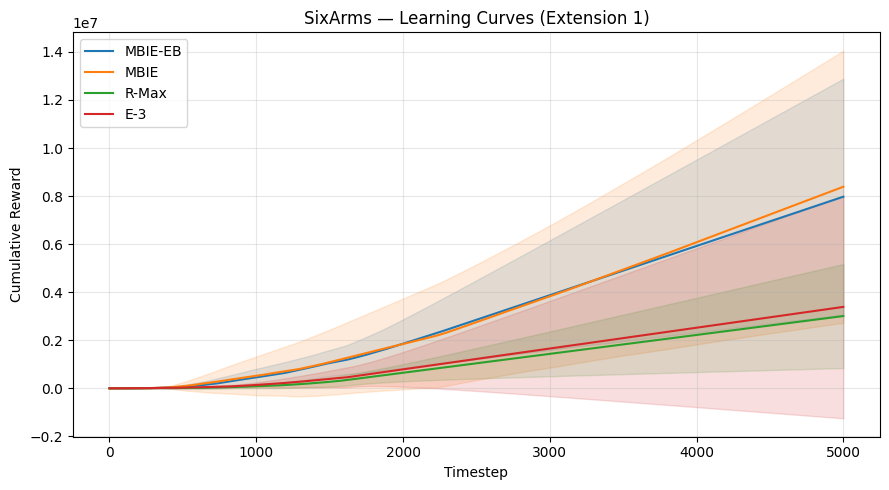

In [31]:
# runs() now returns curves — just call plot_curves
plot_curves(results_rs, 'RiverSwim — Learning Curves (Extension 1)')
plot_curves(results_sa, 'SixArms — Learning Curves (Extension 1)')

## 8. Extension 2 — Sensitivity to m (visit threshold)

`m` controls when a state-action pair is considered "known".
The paper uses `m=16` (RiverSwim) and `m=4` (SixArms) without justification.

**Theorem 1** gives a theoretical optimal m of order:
$$m = O\left(\frac{|S|}{\varepsilon^2(1-\gamma)^4} + \frac{1}{\varepsilon^2(1-\gamma)^4} \ln \frac{|S||A|}{(1-\gamma)\delta}\right)$$

This is astronomically large in practice. We test empirically whether
the paper's choice is near the optimum.

**Expected shape:** U-shaped curve — too small m → inaccurate model → bad policy;
too large m → agent wastes steps exploring when it should exploit.

=== RiverSwim — m sweep ===
  m=1


Experiment: 100%|██████████| 5/5 [00:02<00:00,  1.68it/s]


    MBIE: 3152720


Experiment: 100%|██████████| 5/5 [00:01<00:00,  2.60it/s]


    MBIE-EB: 3082610


...

    MBIE-EB: 6678700


Experiment: 100%|██████████| 5/5 [00:00<00:00, 20.49it/s]


    R-Max: 49024


Experiment: 100%|██████████| 5/5 [00:06<00:00,  1.26s/it]


    E-3: 53299


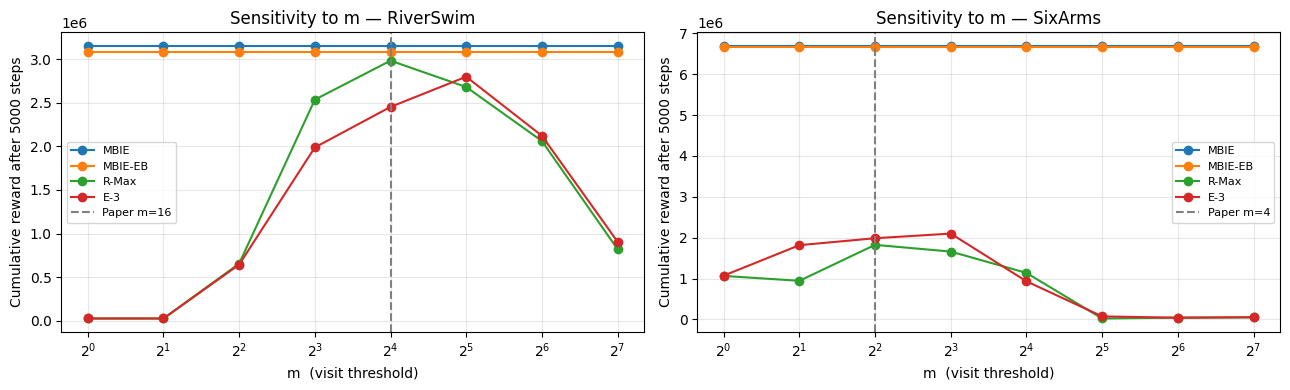

In [32]:
M_GRID = [1, 2, 4, 8, 16, 32, 64, 128]
T_M    = 5   # fewer trials to keep runtime reasonable

def sweep_m(env_fn, agent_factories, m_grid, n_steps, n_trials):
    results = {name: [] for name in agent_factories}
    for m in m_grid:
        print(f'  m={m}')
        for name, factory in agent_factories.items():
            arr, mean, _ = runs(env_fn,
                lambda env, m=m, f=factory: f(m, env),
                n_steps, n_trials)
            results[name].append(mean[-1])
            print(f'    {name}: {mean[-1]:.0f}')
    return results

agents_m_rs = {
    'MBIE':     lambda m, env: MBIE(env, max_reward=R_MAX_RS, discount_factor=GAMMA, A=0.3, B=0.0),
    'MBIE-EB':  lambda m, env: MBIE_EB(env, max_reward=R_MAX_RS, discount_factor=GAMMA, C=0.4),
    'R-Max':    lambda m, env: RMaxAgent(env, GAMMA, m=m, R_max=R_MAX_RS),
    'E-3':      lambda m, env: E3Agent(env, GAMMA, m=m, thresh=0.01, R_max=R_MAX_RS),
}
agents_m_sa = {
    'MBIE':     lambda m, env: MBIE(env, max_reward=R_MAX_SA, discount_factor=GAMMA, A=0.3, B=0.08),
    'MBIE-EB':  lambda m, env: MBIE_EB(env, max_reward=R_MAX_SA, discount_factor=GAMMA, C=0.8),
    'R-Max':    lambda m, env: RMaxAgent(env, GAMMA, m=m, R_max=R_MAX_SA),
    'E-3':      lambda m, env: E3Agent(env, GAMMA, m=m, thresh=0.09, R_max=R_MAX_SA),
}

print('=== RiverSwim — m sweep ===')
m_rs = sweep_m(RiverSwimMDP, agents_m_rs, M_GRID, N_STEPS, T_M)
print('\n=== SixArms — m sweep ===')
m_sa = sweep_m(SixArmsMDP,   agents_m_sa, M_GRID, N_STEPS, T_M)

colors = {'MBIE':'#1f77b4','MBIE-EB':'#ff7f0e','R-Max':'#2ca02c','E-3':'#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, paper_m, title in zip(
        axes, [m_rs, m_sa], [16, 4], ['RiverSwim','SixArms']):
    for name, vals in res.items():
        ax.plot(M_GRID, vals, marker='o', label=name, color=colors[name])
    ax.axvline(paper_m, color='grey', linestyle='--', linewidth=1.5,
               label=f'Paper m={paper_m}')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('m  (visit threshold)')
    ax.set_ylabel('Cumulative reward after 5000 steps')
    ax.set_title(f'Sensitivity to m — {title}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('m_sensitivity.pdf', bbox_inches='tight')
plt.show()

## 9. Extension 3 — Sensitivity of MBIE to A and B

`A` controls the reward confidence interval width: `eps_R = A * R_max / sqrt(n)`.
`B` controls the transition confidence interval width: `eps_T = B / sqrt(n)`.

Paper values: `A=0.3, B=0` (RiverSwim); `A=0.3, B=0.08` (SixArms).

The paper's recommended cell is marked in red on each heatmap.

=== RiverSwim A-B grid ===


Experiment: 100%|██████████| 3/3 [00:01<00:00,  1.81it/s]


  [1/25]  A=0.10  B=0.00  →  3234107


Experiment: 100%|██████████| 3/3 [00:01<00:00,  1.73it/s]


  [2/25]  A=0.10  B=0.05  →  3233107


...

  [23/25]  A=2.00  B=0.08  →  2491211


Experiment: 100%|██████████| 3/3 [00:10<00:00,  3.40s/it]


  [24/25]  A=2.00  B=0.10  →  4618177


Experiment: 100%|██████████| 3/3 [00:09<00:00,  3.13s/it]


  [25/25]  A=2.00  B=0.30  →  5271377


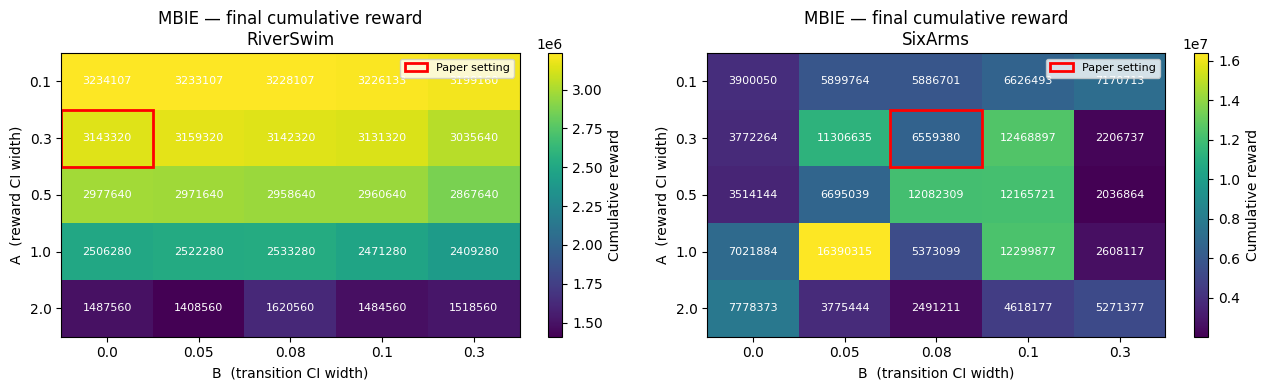

In [33]:
A_GRID   = [0.1, 0.3, 0.5, 1.0, 2.0]
B_GRID   = [0.0, 0.05, 0.08, 0.1, 0.3]
N_AB     = 5000
T_AB     = 3
R_MAX_RS = 10_000
R_MAX_SA = 6_000

def run_grid(env_fn, R_max, gamma=0.95):
    grid  = np.zeros((len(A_GRID), len(B_GRID)))
    total = len(A_GRID) * len(B_GRID)
    done  = 0
    for i, A in enumerate(A_GRID):
        for j, B in enumerate(B_GRID):
            arr, mean, std = runs(
                env_fn,
                lambda env, A=A, B=B: MBIE(env, max_reward=R_max,
                                            discount_factor=gamma, A=A, B=B),
                N_AB, T_AB
            )
            grid[i, j] = mean[-1]
            done += 1
            print(f"  [{done}/{total}]  A={A:.2f}  B={B:.2f}  "
                  f"→  {mean[-1]:.0f}")
    return grid

print("=== RiverSwim A-B grid ===")
grid_rs = run_grid(RiverSwimMDP, R_MAX_RS)

print("\n=== SixArms A-B grid ===")
grid_sa = run_grid(SixArmsMDP, R_MAX_SA)

# plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, grid, title in zip(axes, [grid_rs, grid_sa], ['RiverSwim', 'SixArms']):
    im = ax.imshow(grid, aspect='auto', cmap='viridis')
    ax.set_xticks(range(len(B_GRID))); ax.set_xticklabels(B_GRID)
    ax.set_yticks(range(len(A_GRID))); ax.set_yticklabels(A_GRID)
    ax.set_xlabel('B  (transition CI width)')
    ax.set_ylabel('A  (reward CI width)')
    ax.set_title(f'MBIE — final cumulative reward\n{title}')
    plt.colorbar(im, ax=ax, label='Cumulative reward')
    for i in range(len(A_GRID)):
        for j in range(len(B_GRID)):
            ax.text(j, i, f'{grid[i,j]:.0f}',
                    ha='center', va='center', color='white', fontsize=8)
    paper_B = 0.0 if title == 'RiverSwim' else 0.08
    paper_A = 0.3
    if paper_A in A_GRID:
        ai = A_GRID.index(paper_A)
        bj = min(range(len(B_GRID)), key=lambda j: abs(B_GRID[j] - paper_B))
        ax.add_patch(plt.Rectangle((bj-0.5, ai-0.5), 1, 1,
                                   fill=False, edgecolor='red',
                                   linewidth=2, label='Paper setting'))
        ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('mbie_AB_sensitivity.pdf', bbox_inches='tight')
plt.show()

## 10. Extension 4 — Sensitivity to Discount Factor γ

The paper fixes `γ=0.95`. Theorem 1 shows sample complexity scales as
`O(1/(1-γ)^6)` — extremely sensitive in theory.

**Expected findings:**
- Low γ (myopic): agent ignores distant reward in RiverSwim, stays left
- High γ (0.99): patient but slow — `vmax` is huge, confidence intervals take longer to shrink
- The vertical dashed line marks the paper's γ=0.95

=== RiverSwim — gamma sweep ===
  γ = 0.5


Experiment: 100%|██████████| 3/3 [00:00<00:00,  8.74it/s]


    MBIE: 512120


Experiment: 100%|██████████| 3/3 [00:00<00:00, 12.47it/s]


    MBIE-EB: 484375


...

    MBIE-EB: 7248579


Experiment: 100%|██████████| 3/3 [00:00<00:00, 22.18it/s]


    R-Max: 3615813


Experiment: 100%|██████████| 3/3 [00:15<00:00,  5.30s/it]


    E-3: 2358680


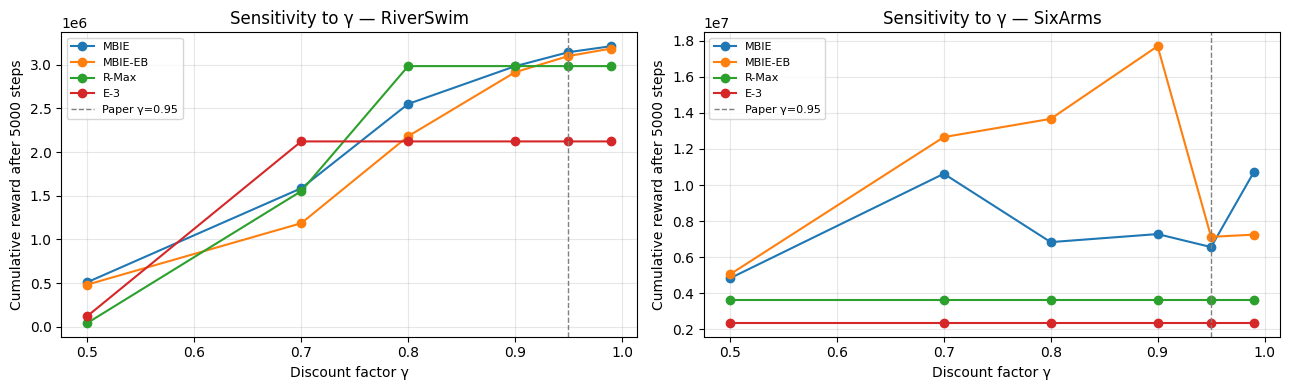

In [34]:
GAMMA_GRID = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
N_G        = 5000
T_G        = 3

def sweep_gamma(env_fn, agent_factories):
    results = {name: [] for name in agent_factories}
    for gamma in GAMMA_GRID:
        print(f"  γ = {gamma}")
        for name, make_agent in agent_factories.items():
            arr, mean, std = runs(
                env_fn,
                make_agent(gamma),
                N_G, T_G
            )
            results[name].append(mean[-1])
            print(f"    {name}: {mean[-1]:.0f}")
    return results

agents_rs = {
    'MBIE':     lambda g: (lambda env: MBIE(env,     max_reward=R_MAX_RS, discount_factor=g, A=0.3, B=0.0)),
    'MBIE-EB':  lambda g: (lambda env: MBIE_EB(env,  max_reward=R_MAX_RS, discount_factor=g, C=0.4)),
    'R-Max':    lambda g: (lambda env: RMaxAgent(env, gamma=g, m=16, R_max=R_MAX_RS)),
    'E-3':      lambda g: (lambda env: E3Agent(env,   gamma=g, m=16, thresh=0.01, R_max=R_MAX_RS)),
}
agents_sa = {
    'MBIE':     lambda g: (lambda env: MBIE(env,     max_reward=R_MAX_SA, discount_factor=g, A=0.3, B=0.08)),
    'MBIE-EB':  lambda g: (lambda env: MBIE_EB(env,  max_reward=R_MAX_SA, discount_factor=g, C=0.8)),
    'R-Max':    lambda g: (lambda env: RMaxAgent(env, gamma=g, m=6,  R_max=R_MAX_SA)),
    'E-3':      lambda g: (lambda env: E3Agent(env,   gamma=g, m=4,  thresh=0.09, R_max=R_MAX_SA)),
}

print("=== RiverSwim — gamma sweep ===")
gamma_rs = sweep_gamma(RiverSwimMDP, agents_rs)

print("\n=== SixArms — gamma sweep ===")
gamma_sa = sweep_gamma(SixArmsMDP, agents_sa)

# plot
colors = {'MBIE':'#1f77b4','MBIE-EB':'#ff7f0e','R-Max':'#2ca02c','E-3':'#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, res, title in zip(axes, [gamma_rs, gamma_sa], ['RiverSwim', 'SixArms']):
    for name, vals in res.items():
        ax.plot(GAMMA_GRID, vals, marker='o', label=name, color=colors[name])
    ax.axvline(0.95, color='grey', linestyle='--', linewidth=1, label='Paper γ=0.95')
    ax.set_xlabel('Discount factor γ')
    ax.set_ylabel('Cumulative reward after 5000 steps')
    ax.set_title(f'Sensitivity to γ — {title}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gamma_sensitivity.pdf', bbox_inches='tight')
plt.show()

## 11. Extension 5 — Epsilon-Greedy Baseline

Epsilon-greedy (ε-greedy) is the canonical *naive* exploration strategy:
with probability ε pick a uniformly random action; otherwise be greedy.
It is ubiquitous in RL as the simplest exploration heuristic, but it has
**no notion of uncertainty** — it cannot concentrate exploration on poorly
understood state-action pairs.

Adding ε-greedy as a baseline to every plot provides a concrete answer to:
> *How much does principled exploration (optimism under uncertainty) matter
> over simply acting randomly some fraction of the time?*

**Design choices:**
- Q is initialised to R\_max (optimistic), ensuring every action is tried at
  least once even without a dedicated uncertainty mechanism.
- Q is updated via incremental sample-mean (α = 1/n), equivalent to standard
  model-free Q-learning with a decreasing step size.
- We use ε = 0.1 as the default across all shared plots (standard literature
  value) and also run a dedicated sensitivity sweep over
  ε ∈ {0.01, 0.05, 0.1, 0.2, 0.3, 0.5}.

**Expected findings:**
- ε-Greedy should fall clearly below all principled algorithms on RiverSwim,
  where the optimal reward requires sustained upstream exploration.
- The gap on SixArms should be even larger: the rarest arm (p=0.01 of
  reaching it) will almost never be discovered by random action selection.
- Learning curves reveal the qualitative difference: principled algorithms
  show a sharp transition when they commit to exploitation; ε-Greedy climbs
  slowly and never fully commits.
- The ε-sweep shows ε-Greedy is relatively flat across ε values, confirming
  that the bottleneck is *how* it explores, not *how much*.


=== Extension 5: running ε-Greedy (ε=0.1) ===


ε-Greedy (RS): 100%|██████████| 20/20 [00:00<00:00, 23.61it/s]


  RiverSwim  ε-Greedy: mean=23350  std=111


ε-Greedy (SA): 100%|██████████| 20/20 [00:00<00:00, 23.44it/s]


  SixArms    ε-Greedy: mean=241415  std=681

=== Extension 5: ε-Greedy epsilon sweep ===


...

  SixArms    ε=0.30: 222653 ± 1830


RS ε=0.5: 100%|██████████| 10/10 [00:00<00:00, 23.16it/s]


  RiverSwim  ε=0.50: 17014 ± 134


SA ε=0.5: 100%|██████████| 10/10 [00:00<00:00, 23.12it/s]


  SixArms    ε=0.50: 201040 ± 2653


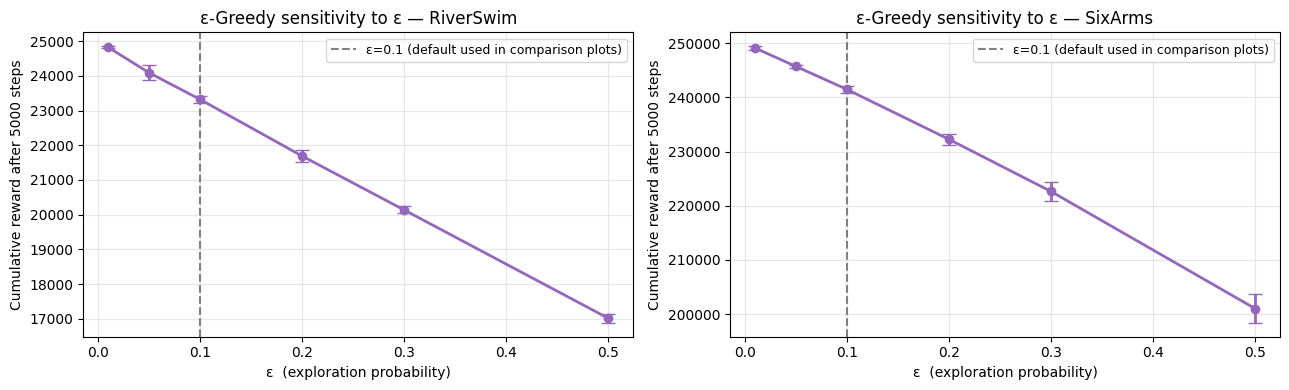

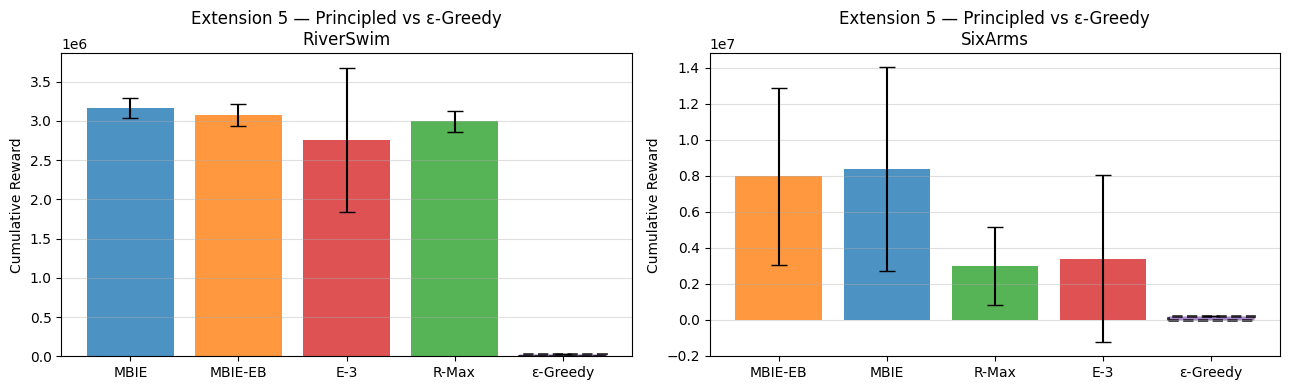

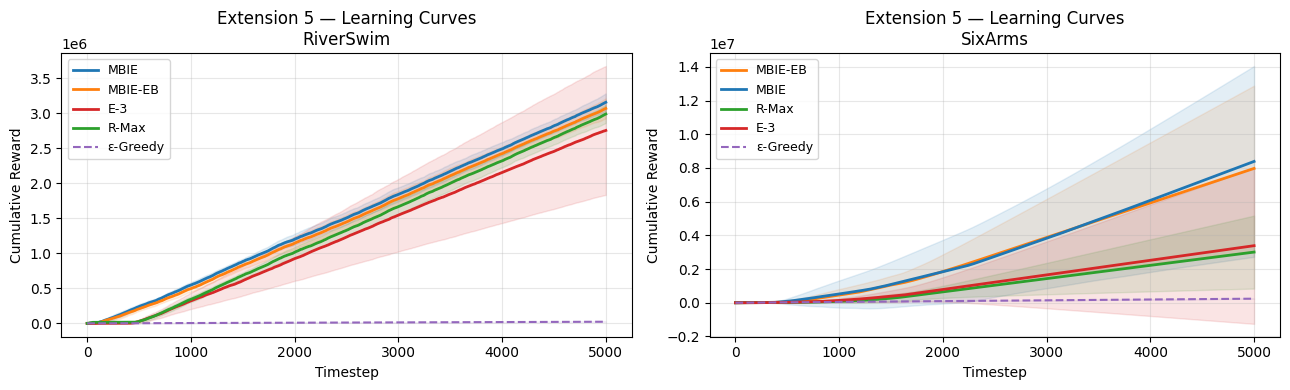


Extension 5 complete.
Key takeaway: the gap between ε-Greedy and principled algorithms shows
how much optimism-based exploration matters over naive random exploration.


In [35]:
# ── Extension 5: Epsilon-Greedy Baseline ─────────────────────────────────────
# Step 1: run ε-Greedy (ε=0.1) on both environments and add to results dicts
# so that Plots 2 & 3 include all 5 algorithms side-by-side.

print("=== Extension 5: running ε-Greedy (ε=0.1) ===")

arr, mean, std = runs(
    RiverSwimMDP,
    lambda env: EpsilonGreedyAgent(env, epsilon=0.1, R_max=R_MAX_RS),
    N_STEPS, N_TRIALS, desc="ε-Greedy (RS)"
)
results_rs['ε-Greedy'] = (arr, mean, std)
print(f"  RiverSwim  ε-Greedy: mean={mean[-1]:.0f}  std={std[-1]:.0f}")

arr, mean, std = runs(
    SixArmsMDP,
    lambda env: EpsilonGreedyAgent(env, epsilon=0.1, R_max=R_MAX_SA),
    N_STEPS, N_TRIALS, desc="ε-Greedy (SA)"
)
results_sa['ε-Greedy'] = (arr, mean, std)
print(f"  SixArms    ε-Greedy: mean={mean[-1]:.0f}  std={std[-1]:.0f}")

# ── Step 2: epsilon sensitivity sweep ────────────────────────────────────────
EPS_GRID = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
T_EPS    = 10

print("\n=== Extension 5: ε-Greedy epsilon sweep ===")

eps_rs_means, eps_rs_stds = [], []
eps_sa_means, eps_sa_stds = [], []

for eps in EPS_GRID:
    arr, mean, std = runs(
        RiverSwimMDP,
        lambda env, e=eps: EpsilonGreedyAgent(env, epsilon=e, R_max=R_MAX_RS),
        N_STEPS, T_EPS, desc=f"RS ε={eps}"
    )
    eps_rs_means.append(mean[-1]); eps_rs_stds.append(std[-1])
    print(f"  RiverSwim  ε={eps:.2f}: {mean[-1]:.0f} ± {std[-1]:.0f}")

    arr, mean, std = runs(
        SixArmsMDP,
        lambda env, e=eps: EpsilonGreedyAgent(env, epsilon=e, R_max=R_MAX_SA),
        N_STEPS, T_EPS, desc=f"SA ε={eps}"
    )
    eps_sa_means.append(mean[-1]); eps_sa_stds.append(std[-1])
    print(f"  SixArms    ε={eps:.2f}: {mean[-1]:.0f} ± {std[-1]:.0f}")

# Plot 1: epsilon sensitivity
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, means, stds, title in zip(
        axes,
        [eps_rs_means, eps_sa_means],
        [eps_rs_stds,  eps_sa_stds],
        ['RiverSwim', 'SixArms']):
    ax.errorbar(EPS_GRID, means, yerr=stds, marker='o', capsize=5,
                color='#9467bd', linewidth=2)
    ax.axvline(0.1, color='grey', linestyle='--', linewidth=1.5,
               label='ε=0.1 (default used in comparison plots)')
    ax.set_xlabel('ε  (exploration probability)')
    ax.set_ylabel('Cumulative reward after 5000 steps')
    ax.set_title(f'ε-Greedy sensitivity to ε — {title}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ext5_epsilon_sensitivity.pdf', bbox_inches='tight')
plt.show()

# ── Plot 2: bar chart — all 5 algorithms ─────────────────────────────────────
alg_colors = {
    'MBIE':     '#1f77b4',
    'MBIE-EB':  '#ff7f0e',
    'R-Max':    '#2ca02c',
    'E-3':      '#d62728',
    'ε-Greedy': '#9467bd',
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, title in zip(axes, [results_rs, results_sa], ['RiverSwim', 'SixArms']):
    names      = list(res.keys())
    means      = [res[k][0].mean() for k in names]
    stds       = [res[k][0].std()  for k in names]
    colors_bar = [alg_colors.get(n, 'steelblue') for n in names]
    bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors_bar, alpha=0.80)
    ax.set_title(f'Extension 5 — Principled vs ε-Greedy\n{title}')
    ax.set_ylabel('Cumulative Reward')
    ax.grid(axis='y', alpha=0.4)
    if 'ε-Greedy' in names:
        idx = names.index('ε-Greedy')
        bars[idx].set_edgecolor('black')
        bars[idx].set_linewidth(2)
        bars[idx].set_linestyle('--')
plt.tight_layout()
plt.savefig('ext5_bar_comparison.pdf', bbox_inches='tight')
plt.show()

# ── Plot 3: learning curves — all 5 algorithms ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, res, title in zip(axes, [results_rs, results_sa], ['RiverSwim', 'SixArms']):
    for name, (_, mean, std) in res.items():
        color = alg_colors.get(name, 'steelblue')
        ls    = '--' if name == 'ε-Greedy' else '-'
        lw    = 1.5 if name == 'ε-Greedy' else 2.0
        steps = np.arange(len(mean))
        ax.plot(steps, mean, label=name, color=color, linestyle=ls, linewidth=lw)
        ax.fill_between(steps, mean - std, mean + std, alpha=0.12, color=color)
    ax.set_title(f'Extension 5 — Learning Curves\n{title}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Cumulative Reward')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ext5_learning_curves.pdf', bbox_inches='tight')
plt.show()

print("\nExtension 5 complete.")
print("Key takeaway: the gap between ε-Greedy and principled algorithms shows")
print("how much optimism-based exploration matters over naive random exploration.")
